In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded=files.upload()

Saving creditcard.csv to creditcard.csv


In [3]:
df=pd.read_csv("creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.describe(include="all")



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [9]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [12]:
df.duplicated().sum()

np.int64(1081)

In [13]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [14]:
df.rename(columns={
    "Time":"TransactionTime",
    "Amount":"TransactionAmount",
    "Class":"IsFraud"
},inplace=True)

In [15]:
df.groupby("IsFraud")["TransactionAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
IsFraud,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [16]:
df['TransactionAmount'].skew()

np.float64(16.978803370060476)

In [17]:
df.columns

Index(['TransactionTime', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
       'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
       'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
       'TransactionAmount', 'IsFraud'],
      dtype='object')

In [18]:
df['TransactionAmount']=np.log1p(df['TransactionAmount'])
df['TransactionAmount'].skew()

np.float64(0.16141018223366638)

In [19]:
df["TransactionHour"] = (df["TransactionTime"] // 3600) % 24

In [20]:
x = df.drop(
    columns=[
        "IsFraud",
        "TransactionTime",
        "TransactionAmount"
    ]
)

y = df["IsFraud"]

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [22]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

In [23]:
isolation_forest.fit(x_train)

IsolationForest(contamination=0.002, n_estimators=200, n_jobs=-1,
                random_state=42)

In [24]:
y_pred = isolation_forest.predict(x_test)

In [25]:
y_pred_mapped = np.where(y_pred == -1, 1, 0)

In [26]:
confusion_matrix(y_test, y_pred_mapped)

array([[56550,   101],
       [   70,    25]])

In [27]:
print(classification_report(y_test, y_pred_mapped, digits=4))

              precision    recall  f1-score   support

           0     0.9988    0.9982    0.9985     56651
           1     0.1984    0.2632    0.2262        95

    accuracy                         0.9970     56746
   macro avg     0.5986    0.6307    0.6124     56746
weighted avg     0.9974    0.9970    0.9972     56746



In [28]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [30]:
contamination_values = [0.002, 0.003, 0.005, 0.01]
results = []

for value in contamination_values:
    model = IsolationForest(
        n_estimators=200,
        contamination=value,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_final)

    val_pred = model.predict(X_val)
    val_pred_mapped = np.where(val_pred == -1, 1, 0)

    results.append({
        "Contamination": value,
        "Precision": precision_score(y_val, val_pred_mapped),
        "Recall": recall_score(y_val, val_pred_mapped),
        "F1 Score": f1_score(y_val, val_pred_mapped)
    })

results_df = pd.DataFrame(results)
results_df

,Contamination,Precision,Recall,F1 Score
0,0.002,0.228261,0.276316,0.250000
1,0.003,0.192000,0.315789,0.238806
2,0.005,0.151786,0.447368,0.226667
3,0.010,0.109890,0.657895,0.188324


In [31]:
final_model = IsolationForest(
    n_estimators=200,
    contamination=0.005,
    random_state=42,
    n_jobs=-1
)

final_model.fit(x_train)

IsolationForest(contamination=0.005, n_estimators=200, n_jobs=-1,
                random_state=42)

In [32]:
final_predictions = final_model.predict(x_test)

final_predictions_mapped = np.where(
    final_predictions == -1,
    1,
    0
)

In [33]:
print(confusion_matrix(y_test, final_predictions_mapped))
print(classification_report(y_test, final_predictions_mapped, digits=4))

[[56384   267]
 [   59    36]]
              precision    recall  f1-score   support

           0     0.9990    0.9953    0.9971     56651
           1     0.1188    0.3789    0.1809        95

    accuracy                         0.9943     56746
   macro avg     0.5589    0.6871    0.5890     56746
weighted avg     0.9975    0.9943    0.9958     56746



In [34]:
anomaly_scores = final_model.decision_function(x_test)

In [35]:
test_results = df.loc[x_test.index, [
    "TransactionTime",
    "TransactionAmount"
]].copy()

test_results["ActualFraud"] = y_test
test_results["PredictedAnomaly"] = final_predictions_mapped
test_results["AnomalyScore"] = anomaly_scores

In [36]:
test_results.sort_values(
    by="AnomalyScore",
    ascending=True
).head(10)

,TransactionTime,TransactionAmount,ActualFraud,PredictedAnomaly,AnomalyScore
274771,166198.0,10.153941,0,1,-0.168522
220090,142019.0,8.693824,0,1,-0.131783
176335,122723.0,7.425119,0,1,-0.129491
206228,136124.0,7.425119,0,1,-0.126414
195218,130956.0,8.354519,0,1,-0.123405
154234,100924.0,0.693147,1,1,-0.122675
153835,100298.0,0.693147,1,1,-0.121029
54018,46253.0,9.384217,0,1,-0.114759
151011,94364.0,0.693147,1,1,-0.113972
219776,141873.0,5.719656,0,1,-0.113854


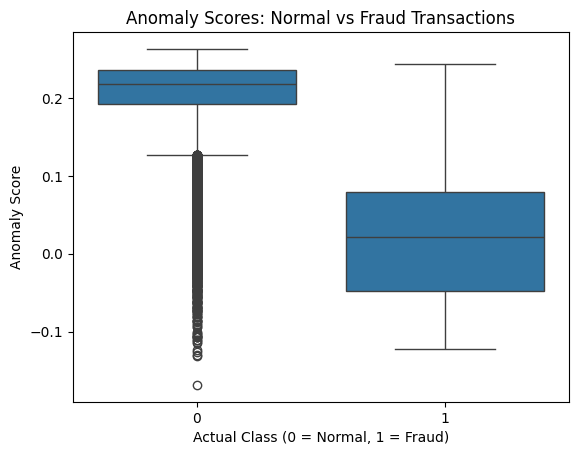

In [37]:
sns.boxplot(
    data=test_results,
    x="ActualFraud",
    y="AnomalyScore"
)

plt.title("Anomaly Scores: Normal vs Fraud Transactions")
plt.xlabel("Actual Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Anomaly Score")
plt.show()

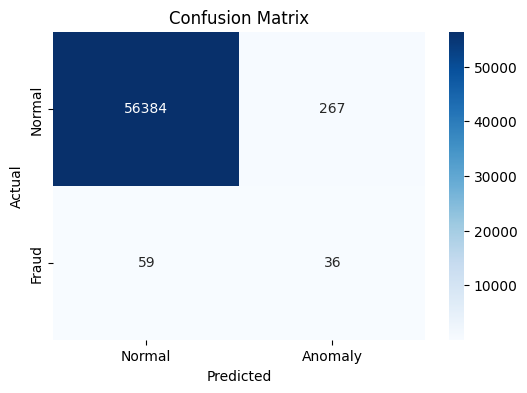

In [38]:
cm = confusion_matrix(y_test, final_predictions_mapped)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
X_train_normal = x_train[y_train == 0]

In [40]:
X_train_normal.shape

(226602, 29)

In [41]:
X_train_normal.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'TransactionHour'],
      dtype='object')

In [42]:
df["LogTransactionAmount"] = df["TransactionAmount"]
df["TransactionAmount"] = np.expm1(df["LogTransactionAmount"])

In [43]:
df[["TransactionAmount", "LogTransactionAmount"]].head()

,TransactionAmount,LogTransactionAmount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [44]:
x = df.drop(
    columns=[
        "IsFraud",
        "TransactionTime",
        "TransactionAmount"
    ]
)

y = df["IsFraud"]

In [45]:
x.shape

(283726, 30)

In [46]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
x_train_normal = x_train[y_train == 0]
x_train_normal.shape

(226602, 30)

In [48]:
improved_model = IsolationForest(
    n_estimators=200,
    contamination=0.005,
    random_state=42,
    n_jobs=-1
)

improved_model.fit(x_train_normal)

IsolationForest(contamination=0.005, n_estimators=200, n_jobs=-1,
                random_state=42)

In [49]:
improved_predictions = improved_model.predict(x_test)

improved_predictions_mapped = np.where(
    improved_predictions == -1,
    1,
    0
)

In [50]:
print(confusion_matrix(y_test, improved_predictions_mapped))

print(
    classification_report(
        y_test,
        improved_predictions_mapped,
        digits=4
    )
)

[[56340   311]
 [   56    39]]
              precision    recall  f1-score   support

           0     0.9990    0.9945    0.9968     56651
           1     0.1114    0.4105    0.1753        95

    accuracy                         0.9935     56746
   macro avg     0.5552    0.7025    0.5860     56746
weighted avg     0.9975    0.9935    0.9954     56746



In [51]:
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [52]:
x_train_final_normal = x_train_final[y_train_final == 0]
x_train_final_normal.shape

(181282, 30)

In [53]:
contamination_values = [0.001, 0.002, 0.003, 0.005, 0.01]
tuning_results = []

for value in contamination_values:
    model = IsolationForest(
        n_estimators=200,
        contamination=value,
        random_state=42,
        n_jobs=-1
    )

    model.fit(x_train_final_normal)

    val_predictions = model.predict(x_val)
    val_predictions_mapped = np.where(
        val_predictions == -1,
        1,
        0
    )

    tuning_results.append({
        "Contamination": value,
        "Precision": precision_score(y_val, val_predictions_mapped),
        "Recall": recall_score(y_val, val_predictions_mapped),
        "F1Score": f1_score(y_val, val_predictions_mapped)
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df

,Contamination,Precision,Recall,F1Score
0,0.001,0.288462,0.197368,0.234375
1,0.002,0.166667,0.236842,0.195652
2,0.003,0.174194,0.355263,0.233766
3,0.005,0.150000,0.513158,0.232143
4,0.010,0.102362,0.684211,0.178082


In [54]:
final_model = improved_model

In [55]:
model_artifact = {
    "model": final_model,
    "features": x.columns.tolist()
}

joblib.dump(
    model_artifact,
    "transaction_anomaly_detector.pkl"
)

['transaction_anomaly_detector.pkl']

In [56]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib


# Page configuration
st.set_page_config(
    page_title="Transaction Anomaly Detector",
    page_icon="💳",
    layout="wide"
)


# Simple styling
st.markdown(
    """
    <style>
    .main-title {
        background: linear-gradient(90deg, #1e3a8a, #0f766e);
        color: white;
        padding: 25px;
        border-radius: 15px;
        text-align: center;
        margin-bottom: 25px;
    }

    .main-title h1 {
        margin: 0;
        color: white;
    }

    .main-title p {
        margin-top: 8px;
        color: #e0f2fe;
    }

    div[data-testid="stMetric"] {
        background-color: white;
        border: 1px solid #e5e7eb;
        padding: 15px;
        border-radius: 12px;
    }
    </style>
    """,
    unsafe_allow_html=True
)


# Header
st.markdown(
    """
    <div class="main-title">
        <h1>💳 Transaction Anomaly Detector</h1>
        <p>
            Upload transaction data and identify
            potentially suspicious transactions
        </p>
    </div>
    """,
    unsafe_allow_html=True
)


# Basic project information
st.info(
    "This application uses an Isolation Forest model "
    "to identify unusual transaction patterns."
)


# Upload CSV
uploaded_file = st.file_uploader(
    "Upload your transaction CSV file",
    type=["csv"]
)


# Run only when a file is uploaded
if uploaded_file is not None:

    # Read CSV file
    data = pd.read_csv(uploaded_file)

    st.subheader("Uploaded Data")

    st.dataframe(
        data.head(),
        use_container_width=True
    )


    # Columns required by the model
    required_columns = (
        ["Time"]
        + [f"V{i}" for i in range(1, 29)]
        + ["Amount"]
    )


    # Find missing columns
    missing_columns = []

    for column in required_columns:

        if column not in data.columns:

            missing_columns.append(column)


    # Stop if required columns are missing
    if len(missing_columns) > 0:

        st.error(
            "Missing columns: "
            + ", ".join(missing_columns)
        )

        st.stop()


    # Load saved model
    try:

        artifact = joblib.load(
            "transaction_anomaly_detector.pkl"
        )

        model = artifact["model"]
        features = artifact["features"]

    except FileNotFoundError:

        st.error(
            "Model file not found. Keep "
            "transaction_anomaly_detector.pkl "
            "in the same folder as app.py."
        )

        st.stop()


    # Create TransactionHour
    data["TransactionHour"] = (
        data["Time"] // 3600
    ) % 24


    # Apply log transformation to Amount
    data["LogTransactionAmount"] = np.log1p(
        data["Amount"]
    )


    # Select V1 to V28
    model_input = data[
        [f"V{i}" for i in range(1, 29)]
        + [
            "TransactionHour",
            "LogTransactionAmount"
        ]
    ]


    # Keep features in the same training order
    model_input = model_input[features]


    # Predict transactions
    with st.spinner(
        "Checking transactions..."
    ):

        predictions = model.predict(
            model_input
        )

        anomaly_scores = model.decision_function(
            model_input
        )


    # Convert model output into labels
    data["Prediction"] = np.where(
        predictions == -1,
        "Suspicious",
        "Normal"
    )


    # Add anomaly score
    data["AnomalyScore"] = anomaly_scores


    # Calculate counts
    total_transactions = len(data)

    suspicious_transactions = (
        data["Prediction"] == "Suspicious"
    ).sum()

    normal_transactions = (
        total_transactions
        - suspicious_transactions
    )

    anomaly_rate = (
        suspicious_transactions
        / total_transactions
    ) * 100


    # Display summary
    st.subheader("Prediction Summary")

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Transactions",
        total_transactions
    )

    col2.metric(
        "Normal",
        normal_transactions
    )

    col3.metric(
        "Suspicious",
        suspicious_transactions
    )

    col4.metric(
        "Anomaly Rate",
        f"{anomaly_rate:.2f}%"
    )


    # Show status
    if suspicious_transactions > 0:

        st.warning(
            f"{suspicious_transactions} suspicious "
            "transaction(s) detected."
        )

    else:

        st.success(
            "No suspicious transactions detected."
        )


    # Create two tabs
    tab1, tab2 = st.tabs(
        [
            "All Predictions",
            "Suspicious Transactions"
        ]
    )


    # All transaction results
    with tab1:

        st.dataframe(
            data,
            use_container_width=True
        )


    # Only suspicious transactions
    with tab2:

        suspicious_data = data[
            data["Prediction"] == "Suspicious"
        ].sort_values(
            by="AnomalyScore"
        )

        if suspicious_data.empty:

            st.success(
                "No suspicious transactions found."
            )

        else:

            st.dataframe(
                suspicious_data,
                use_container_width=True
            )


    # Convert results into CSV
    result_csv = data.to_csv(
        index=False
    ).encode("utf-8")


    # Download button
    st.download_button(
        label="Download Prediction Results",
        data=result_csv,
        file_name="transaction_predictions.csv",
        mime="text/csv"
    )


else:

    st.write(
        "Upload a CSV file to start anomaly detection."
    )

Writing app.py


In [57]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [58]:
import sklearn as sk
print(sk.__version__)
print(joblib.__version__)
print(np.__version__)
print(pd.__version__)

1.6.1
1.5.3
2.0.2
2.2.2


In [59]:
!zip -r transaction-anomaly-detector.zip \
    app.py \
    requirements.txt \
    transaction_anomaly_detector.pkl \
    sample_transactions.csv

	zip warning: name not matched: sample_transactions.csv
  adding: app.py (deflated 66%)
  adding: requirements.txt (stored 0%)
  adding: transaction_anomaly_detector.pkl (deflated 74%)


In [60]:
files.download("transaction-anomaly-detector.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>